In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
!pip install whittaker_eilers

from whittaker_eilers import WhittakerSmoother

!pip install roifile

!unzip RoiSet.zip -d RoiSet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 6.4 MB/s eta 0:00:00
Archive:  RoiSet.zip
  inflating: RoiSet/A4l.roi          
  inflating: RoiSet/A3l.roi          
  inflating: RoiSet/A2l.roi          
  inflating: RoiSet/A5l.roi          
  inflating: RoiSet/A1l.roi          
  inflating: RoiSet/A7l.roi          
  inflating: RoiSet/A6l.roi          
  inflating: RoiSet/A9r.roi          
  inflating: RoiSet/A8r.roi          
  inflating: RoiSet/A7r.roi          
  inflating: RoiSet/A6r.roi          
  inflating: RoiSet/A5r.roi          
  inflating: RoiSet/A4r.roi          
  inflating: RoiSet/A3r.roi          
  inflating: RoiSet/A2r.roi          
  inflating: RoiSet/T3r.roi          
  inflating: RoiSet/A8l.roi          
  inflating: RoiSet/A9l.roi          
  inflating: RoiSet/T3l.roi          
  inflating: RoiSet/A1r.roi          


In [69]:
###########################             ###########################
########################### MAIN fUNCTION ###########################
###########################             ###########################

# To apply an ROI mask to your calcium imaging analysis:

# Create a binary mask that marks your regions of interest
# Modify to only process pixels within this mask

#### rois coordinates stored in rois_coordinates

########### OPTMISED + ROI
def DFOF_optimized_roi(image_stack, dict_rois_name_xy,  opto_list):
    total_frame, total_pixel = image_stack.shape[0:2]
    frame_rate = 50
    smooth_frame = 12 * frame_rate // 2  # smooth over 2 seconds


    # strategy for opto-genetics correction: take an ROI of same size outside of image and average it out of all ROI traces
    # opto_list contains True/false to see if there is opto stimulus, stimulus start time in frame number and stimulus duration in frames
    opto_is_used = opto_list[0]

    if opto_is_used == True:
      stimulus_start = opto_list[1]
      stimulus_duration = opto_list[2]


    ### initialise dictionaries to stock information

    dict_rois_df_f = dict()

    dict_rois_baseline = dict()

    dict_rois_df = dict()

    dict_opto_df = dict()

########## loop over every ROI
    # Create a binary mask that marks your regions of interest
    for roi_name, roi_coordinates in dict_rois_name_xy.items():
      #run the function per key and store result in new dictionary
      print(roi_name)

      ############################ make the ROI a disk mask ############################

      # Compute the center of the circle
      center_x = np.mean(roi_coordinates[:, 0])
      center_y = np.mean(roi_coordinates[:, 1])

      # Compute the radius as the maximum distance from the center to the boundary points
      radius = int(np.max(np.linalg.norm(roi_coordinates - [center_x, center_y], axis=1)))
      # Create a coordinate grid for the entire image
      y_indices, x_indices = np.meshgrid(np.arange(total_pixel), np.arange(total_pixel), indexing="ij")

      # Compute the distance from each pixel to the circle center
      distance_from_center = np.sqrt((x_indices - center_x) ** 2 + (y_indices - center_y) ** 2)

      # Create the binary mask (True for pixels inside the circle, False outside)
      roi_mask = distance_from_center <= radius

      # Get indices of pixels inside the ROI
      roi_indices =(np.where(roi_mask))
      # Unpack x and y coordinates for advanced indexing
      roi_y = roi_indices[0].astype(int)
      roi_x = roi_indices[1].astype(int)

      # Pre-allocate arrays with the same shape as image_stack
      pixel_roi = len(roi_x)


    ############################ Optogenetics artifact correction ############################

    # add ROI with center (radius,radius) location as (x,y) so it is in the right corner away from stimulus
    # compute the baseline of ROI (not of individual pixels) and addition of optogenetics --> only take the addition of optogenetics (opto stim signal - baseline)
    # in df_f: f-f0/f0, substract it to f - substract it to df of ROI of interest
    ############################ Optogenetics artifact correction ############################
    ### keep y-coord the same or a multiple of the space between two of the optogenetics stripe
      space_btw_opto_stripes = 8

      # Find the boundaries of the rectangle enclosing all ROIs
      all_roi_coords = np.concatenate(list(dict_rois_name_xy.values()))
      min_x = int(np.min(all_roi_coords[:, 0]))
      max_x = int(np.max(all_roi_coords[:, 0]))
      min_y = int(np.min(all_roi_coords[:, 1]))
      max_y = int(np.max(all_roi_coords[:, 1]))

      ############# make the opto ROI a disk mask #############
      # Calculate opto ROI center outside the rectangle, at the same y-coordinate
    # Translate the original ROI coordinates

      # Usage example
      if opto_is_used:
        # Get image dimensions
        image_height, image_width = total_pixel, total_pixel

        # Place the reference ROI
        opto_roi_x, opto_roi_y = place_reference_roi(
            roi_x, roi_y,
            min_x, max_x, min_y, max_y,
            radius, image_width, image_height,
            space_btw_opto_stripes
        )

        # Visualize the ROIs
        plt.plot(roi_x, roi_y, 'r-')
        plt.plot(opto_roi_x, opto_roi_y, 'b-')
        plt.plot([min_x, max_x, max_x, min_x, min_x], [min_y, min_y, max_y, max_y, min_y], 'g--')


        ### Initialize opto_df with the correct shape
        opto_df = np.zeros((total_frame, (pixel_roi)))  # Shape: (total_frames, num_pixels_in_ROI)

        #print(opto_roi_x, opto_roi_y)
        ##### Calculate baseline for each pixel in the opto ROI
        opto_baseline = np.mean(image_stack[:stimulus_start - 1, opto_roi_y, opto_roi_x], axis=0)



        ##### Compute the df of opto artifact for each pixel
        for frame in range(stimulus_start,stimulus_start+stimulus_duration):
            opto_df[frame, :] = image_stack[frame, opto_roi_y, opto_roi_x] - (opto_baseline)  # Subtract baseline from each pixel

        dict_opto_df[roi_name] = opto_df  # Store pixel-wise opto_df in the dictionary

      elif opto_is_used == False:
        opto_df = np.zeros((total_frame, (pixel_roi)))  # Shape: (total_frames, num_pixels_in_ROI)
        dict_opto_df[roi_name] = opto_df


      ############################ COMPUTE - DF - BASELINE - DF F ############################

      ### initialise arrays
      df = np.zeros((total_frame,pixel_roi))
      df_f = np.zeros((total_frame,pixel_roi))
      baseline = np.zeros((total_frame,pixel_roi))

      ### First section: frames with increasing window sizes
      for frame in range(smooth_frame):
          # Use vectorized percentile computation over all pixels at once
          window = image_stack[:smooth_frame + frame, roi_y, roi_x]
          #print(window.shape)
          baseline[frame] = np.mean(window, axis = 0) ### axis = 0 means in this case along the time series for each individual pixel, not across pixels
          a = image_stack[frame, roi_y, roi_x]
          b = baseline[frame]
  # Use np.less to perform element-wise comparison and np.where to assign values based on the comparison. instead of using an if statement, I've used np.where.    np.less is used to compare the two arrays (image_stack[frame] and baseline[frame]) element-wise. Then np.where assigns a value of 0 where the comparison is True (i.e., where image_stack[frame] is less than baseline[frame]), and assigns the result of image_stack[frame] - baseline[frame] where the comparison is False. This allows for element-wise operations without ambiguity.
          df[frame] = np.where(np.less(image_stack[frame, roi_y, roi_x], baseline[frame]), a - b, image_stack[frame, roi_y, roi_x] - baseline[frame])

          df_f[frame] = df[frame] / baseline[frame]
          # print(f'Frame {frame+1}/{total_frame}')

      # Middle section: frames with full symmetric window
      for frame in range(smooth_frame, total_frame - smooth_frame + 1):
          window = image_stack[frame - smooth_frame:frame + smooth_frame, roi_y, roi_x]
          baseline[frame] = np.mean(window, axis = 0)

          a = image_stack[frame, roi_y, roi_x]
          b = baseline[frame]
          df[frame] = np.where(np.less(image_stack[frame, roi_y, roi_x], baseline[frame]), a - b, image_stack[frame, roi_y, roi_x] - baseline[frame])


          df_f[frame] = df[frame] / baseline[frame]
          #print(f'Frame {frame+1}/{total_frame}')

      # Last section: frames with decreasing window sizes at the end
      for frame in range(total_frame - smooth_frame + 1, total_frame):
          window = image_stack[frame - smooth_frame:total_frame, roi_y, roi_x]
          baseline[frame] = np.mean(window, axis = 0)

          a = image_stack[frame, roi_y, roi_x]
          b = baseline[frame]
          df[frame] = np.where(np.less(image_stack[frame, roi_y, roi_x], baseline[frame]), a - b, image_stack[frame, roi_y, roi_x] - baseline[frame])

          df_f[frame] = df[frame] / baseline[frame]
          #print(f'Frame {frame+1}/{total_frame}')

      df_f[759]=df_f[757] ### artifact at frame 759 corrected by minimal interpolation with previous data point
      df_f[758]=df_f[757]


      dict_rois_df_f[roi_name] = df_f
      dict_rois_baseline[roi_name] = baseline
      dict_rois_df[roi_name] = df

    return dict_rois_baseline, dict_rois_df, dict_rois_df_f, dict_opto_df


def place_reference_roi(roi_x, roi_y, min_x, max_x, min_y, max_y, radius, image_width, image_height, space_btw_opto_stripes, opto_is_used=True):
    """
    Places a reference ROI outside the bounding box of the object for artifact correction.

    Parameters:
    -----------
    roi_x, roi_y : numpy arrays
        Coordinates of the original ROI
    min_x, max_x, min_y, max_y : int
        Bounding box coordinates of the object
    radius : int
        Radius of the ROI
    image_width, image_height : int
        Dimensions of the image
    space_btw_opto_stripes : int
        Space between optogenetic stimulation stripes
    opto_is_used : bool
        Whether optogenetics is used

    Returns:
    --------
    opto_roi_x, opto_roi_y : numpy arrays
        Coordinates of the reference ROI for artifact correction
    """
    if not opto_is_used:
        return roi_x, roi_y

    # Initialize reference ROI coordinates (start with the original ROI)
    opto_roi_x = roi_x.copy()
    opto_roi_y = roi_y.copy()

    # Calculate the center of the original ROI
    center_x = int(np.mean(roi_x))
    center_y = int(np.mean(roi_y))

    # Calculate the center of the bounding box
    bbox_center_x = (min_x + max_x) // 2
    bbox_center_y = (min_y + max_y) // 2

    # Calculate bbox dimensions
    bbox_width = max_x - min_x
    bbox_height = max_y - min_y

    # Safety margin (pixels to stay away from the image edge)
    margin = 20

    # First priority: Try to place the reference ROI horizontally away from the bounding box
    # while keeping the same y-coordinate (for consistent artifact correction)

    # Option 1: Place the reference ROI to the right of the bounding box
    right_x = max_x + radius + 50
    if right_x < image_width - margin:
        # Shift the reference ROI to the right
        x_shift = right_x - center_x
        opto_roi_x = roi_x + x_shift
        return opto_roi_x, opto_roi_y

    # Option 2: Place the reference ROI to the left of the bounding box
    left_x = min_x - radius - 50
    if left_x > margin:
        # Shift the reference ROI to the left
        x_shift = left_x - center_x
        opto_roi_x = roi_x + x_shift
        return opto_roi_x, opto_roi_y

    # If we can't place it horizontally with the same y-coordinate,
    # try placing it vertically with a shifted y-coordinate

    # Option 3: Place the reference ROI above the bounding box
    top_distance = image_height - margin - max_y
    if top_distance > 6 * space_btw_opto_stripes and (roi_y + 6 * space_btw_opto_stripes > max_y + margin).any()  :   ### use and shift_y + roi_y > bboox_y
        # Place reference ROI above the bounding box
        y_shift =   6 * space_btw_opto_stripes
        opto_roi_y = roi_y + y_shift
        return opto_roi_x, opto_roi_y

    # Option 4: Place the reference ROI below the bounding box
    bottom_distance = min_y - margin
    if bottom_distance > 6 * space_btw_opto_stripes and (roi_y - 6 * space_btw_opto_stripes < min_y - margin).any() :

        # Place reference ROI below the bounding box
        y_shift = - 6 * space_btw_opto_stripes
        opto_roi_y = roi_y + y_shift
        return opto_roi_x, opto_roi_y

    # Option 5: If we can't place it nicely, find the corner furthest from the object
    # Define the four corners of the image (with margin)
    corners = [
        (margin, margin),                         # Top-left
        (margin, image_height - margin),          # Bottom-left
        (image_width - margin, margin),           # Top-right
        (image_width - margin, image_height - margin)  # Bottom-right
    ]

    # Find the corner that's furthest from the bounding box center
    max_distance = 0
    best_corner_raw = corners[0]

    for corner in corners:
        distance = ((corner[0] - bbox_center_x) ** 2 + (corner[1] - bbox_center_y) ** 2) ** 0.5
        if distance > max_distance:
            max_distance = distance
            best_corner_raw = corner


    # Shift the reference ROI to the best corner

    # Now, adjust the y-coordinate of the best corner to be a multiple of space_btw_opto_stripes
    target_y = best_corner_raw[1]

    # Find the closest multiple of space_btw_opto_stripes to the target_y
    closest_multiple = round((target_y - max_y)/ space_btw_opto_stripes)


    adjusted_y = roi_y +  closest_multiple * space_btw_opto_stripes

    # Calculate shifts based on the adjusted corner
    x_shift = best_corner_raw[0] - center_x
    y_shift = adjusted_y

    # Apply the shifts to the original ROI coordinates
    opto_roi_x =  roi_x + x_shift
    opto_roi_y =  y_shift

    # # Final safety check: make sure the coordinates are within image bounds with margin
    # opto_roi_x = np.clip(opto_roi_x, margin, image_width - margin - 1) # -1 to stay within bounds
    # opto_roi_y = np.clip(opto_roi_y, margin, image_height - margin - 1) # -1 to stay within bounds

    print(f'CCCC: Placed at adjusted corner ({opto_roi_x.mean():.2f}, {opto_roi_y.mean():.2f})')
    print(f'before ({roi_x.mean():.2f}, {roi_y.mean():.2f})')



    return opto_roi_x, opto_roi_y

In [33]:
def plot_image_overlays(image, overlays, roi_names, opto_overlays_xy=None, **kwargs): # Added opto_overlays_xy
    """Plot image, original overlays, and opto overlays using matplotlib."""
    fig, ax = plt.subplots()
    ax.imshow(image, cmap='plasma')

    # Plot original ROIs
    if not isinstance(overlays, list):
        overlays = [overlays]

    for i, overlay in enumerate(overlays):
        roi = overlay
        roi.plot(ax, color='gray', **kwargs) # Original ROIs in gray

        # Add text label for original ROI
        coordinates = roi.coordinates()
        x_center = np.mean(coordinates[:, 0])
        y_center = np.mean(coordinates[:, 1])
        ax.text(x_center, y_center, roi_names[i], color='white', fontsize=8) # Adjust fontsize as needed

    # Plot opto ROIs if provided
    if opto_overlays_xy is not None:
        for roi_name, (opto_x, opto_y) in opto_overlays_xy.items():
             # Assuming opto_overlays_xy contains (x, y) coordinate arrays
             ax.plot(opto_x, opto_y, 'b-', label=f'Opto {roi_name}', linewidth=0.5, alpha=0.7) # Opto ROIs in blue
             # You might want to add a text label for the opto ROI too if needed

    ax.axis('off')
    # Consider adding a combined legend if needed, or plot opto ROIs without labels
    plt.title("Image with Original and Opto ROIs")
    plt.show()


POTENT~1.tif
press enter if no filter image(else give name):
Optogenetics Stimulation ? press enter if yes (else type no):
Please enter stimulus start frame (enter is default: frame 760): 
760
Please enter stimulus duration (enter is default: 250 frames): 
250
A1r
A5l
A3l
A7l
A3r
A6r
A7r
CCCC: Placed at adjusted corner (20.63, 201.27)
before (57.63, 129.27)
A6l
A8l
A4r
T3l
CCCC: Placed at adjusted corner (20.83, 196.50)
before (232.83, 124.50)
T3r
A2l
A1l
CCCC: Placed at adjusted corner (20.83, 194.50)
before (203.83, 122.50)
A5r
A9l
A9r
A2r
A4l
A8r
CCCC: Placed at adjusted corner (20.50, 197.83)
before (41.50, 125.83)


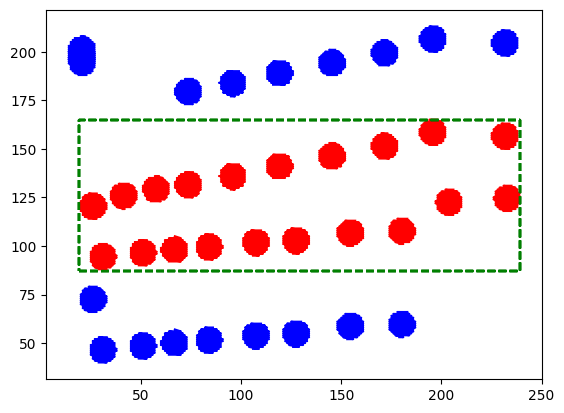

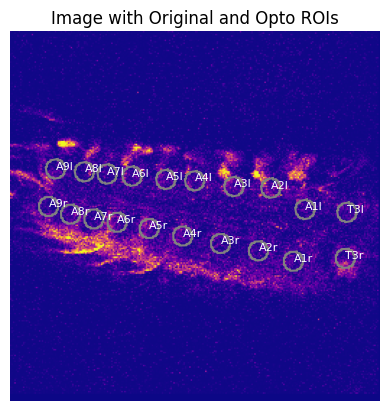

In [70]:
###########################             ###########################
########################### MAIN SCRIPT ###########################
###########################             ###########################

import imageio
from tifffile import imread
import skimage as ski
import skimage.io as skio

import roifile
from roifile import roiread
from roifile import ImagejRoi

import os

image = [f for f in os.listdir('/content/') if f.endswith('.tif')]

if len(image) > 1 :
  print(image)
  image = input('what is the name of image:')
else :
  image = image[0]
  print(image)
image_data = ski.io.imread(image)
#image_data = ski.io.imread('head cast.tif')

filter = input('press enter if no filter image(else give name):')
# image_filtered = ski.filters.gaussian(image_data, sigma=1)

if filter != '':
  image_filtered = ski.io.imread(filter)

image_filtered = image_data


#image_filtered = ski.io.imread('filtered_gaussian_1um_headcast.tif')
# image_filtered = imread('3d_filtered_gaussian_2um_headcast.tif')

################## ROIS ##################

# Get a list of all .roi files in the RoiSet directory
RoiSet = [f for f in os.listdir('/content/RoiSet') if f.endswith('.roi')]

# Load ROIs file
rois = []
rois_coordinates = []

dict_rois_name_xy = dict()

for roi_file in RoiSet:
  # read ROIs 1 by 1 from RoiSet folder
  roi = roiread('/content/RoiSet/'+roi_file)
  rois.append(roi)
  rois_coordinates.append(roi.coordinates())

  stripped_roi_file = roi_file.replace('.roi', '')

  ### create dictionnary that links name to coordinates
  dict_rois_name_xy[stripped_roi_file] = roi.coordinates()


################## OPTOGENETICS CORRECTION ##################

opto = input('Optogenetics Stimulation ? press enter if yes (else type no):')
# image_filtered = ski.filters.gaussian(image_data, sigma=1)

opto_list=[] # opto_list contains True/false to see if there is opto stimulus, stimulus start time in frame number and stimulus duration in frames

if opto != 'no':
  opto_list.append(True)
  stimulus_start = input("Please enter stimulus start frame (enter is default: frame 760): ")
  stimulus_start = int(stimulus_start) if stimulus_start else 760
  print(stimulus_start)
  opto_list.append(stimulus_start)
  stimulus_duration = input("Please enter stimulus duration (enter is default: 250 frames): ")
  stimulus_duration = int(stimulus_duration) if stimulus_duration else 250
  print(stimulus_duration)
  opto_list.append(stimulus_duration)

if opto != 'no':
  opto_list.append(False)
# plt.imshow(image_data[0])
# plt.axis('off')
# plt.show()

dict_rois_baseline, dict_rois_df, dict_rois_df_f, dict_opto_df= DFOF_optimized_roi(image_data, dict_rois_name_xy, opto_list)

roi_names = list(dict_rois_name_xy.keys())

plot_image_overlays(image_filtered[600], rois, roi_names )


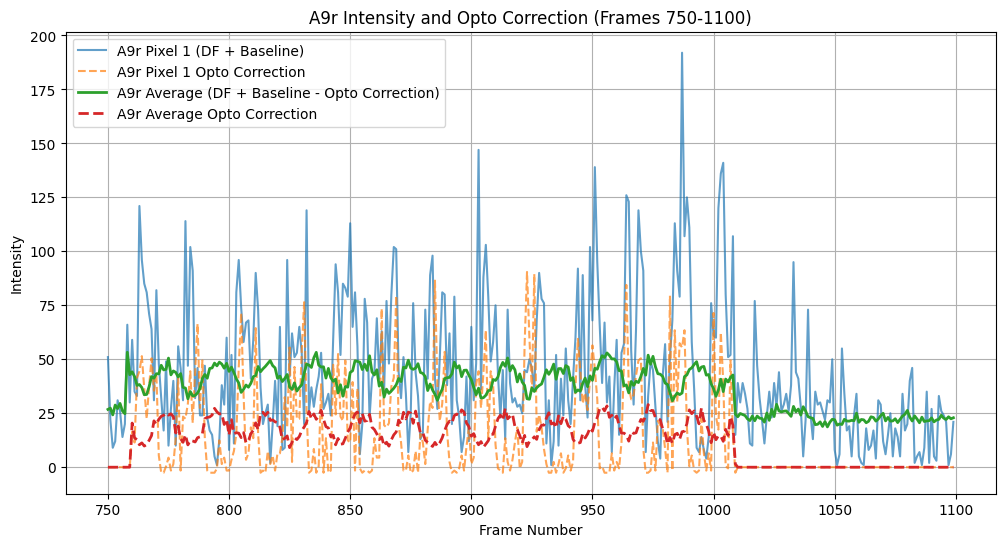

In [71]:
# prompt: i want to plot the opto correction as well as intensity of A2r, plot one trace for a single pixel and the average, only between time frame 750:1100, not the df_f but df + baseline

# Select the ROI you want to plot (e.g., 'A2r')
roi_to_plot = 'A9r'

# Ensure the ROI exists in the dictionaries
if roi_to_plot in dict_rois_df and roi_to_plot in dict_rois_baseline and roi_to_plot in dict_opto_df:
    df_data = dict_rois_df[roi_to_plot]
    baseline_data = dict_rois_baseline[roi_to_plot]
    opto_correction_data = dict_opto_df[roi_to_plot]

    # Combine df and baseline for the corrected trace
    corrected_trace_pixel = df_data + baseline_data
    corrected_trace = df_data + baseline_data - opto_correction_data


    # Time frame slice
    start_frame = 750
    end_frame = 1100

    # Apply the time frame slice to all data
    corrected_trace_sliced = corrected_trace_pixel[start_frame:end_frame, :]
    opto_correction_sliced = opto_correction_data[start_frame:end_frame, :]


    # Get a single pixel trace (e.g., the first pixel in the ROI)
    single_pixel_index = 0
    single_pixel_trace = corrected_trace_sliced[:, single_pixel_index]
    single_pixel_opto_correction = opto_correction_sliced[:, single_pixel_index]

    # Calculate the average trace across all pixels in the ROI
    average_trace = np.mean(corrected_trace_sliced, axis=1)
    average_opto_correction = np.mean(opto_correction_sliced, axis=1)


    # Create time axis for plotting
    time_axis = np.arange(start_frame, end_frame)

    # Plotting
    plt.figure(figsize=(12, 6))

    # Plot single pixel trace and its opto correction
    plt.plot(time_axis, single_pixel_trace, label=f'{roi_to_plot} Pixel {single_pixel_index + 1} (DF + Baseline)', alpha=0.7)
    plt.plot(time_axis, single_pixel_opto_correction, label=f'{roi_to_plot} Pixel {single_pixel_index + 1} Opto Correction', linestyle='--', alpha=0.7) # Plot opto correction offset

    # Plot average trace and its opto correction
    plt.plot(time_axis, average_trace, label=f'{roi_to_plot} Average (DF + Baseline - Opto Correction)', linewidth=2)
    plt.plot(time_axis, average_opto_correction, label=f'{roi_to_plot} Average Opto Correction', linestyle='--', linewidth=2) # Plot opto correction offset


    plt.xlabel('Frame Number')
    plt.ylabel('Intensity')
    plt.title(f'{roi_to_plot} Intensity and Opto Correction (Frames {start_frame}-{end_frame})')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f"ROI '{roi_to_plot}' not found in analysis results.")


<ipython-input-72-2e728fbe0cdd>:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


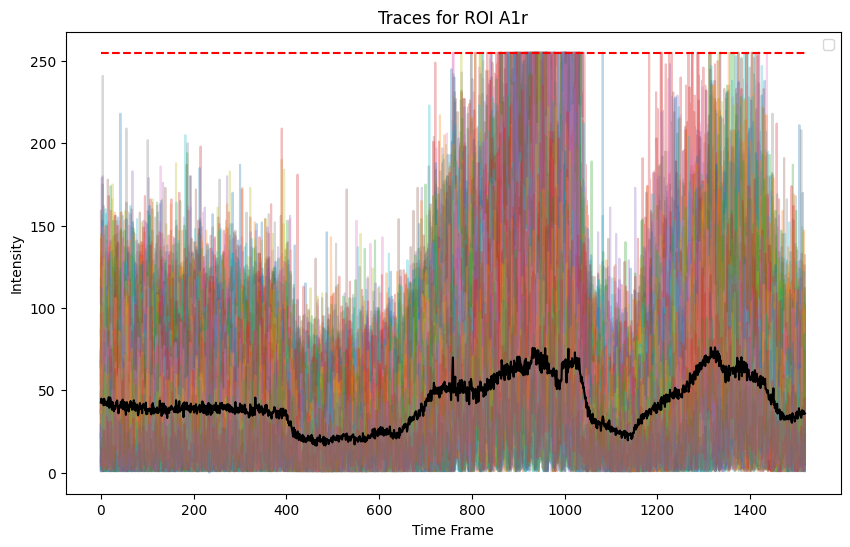

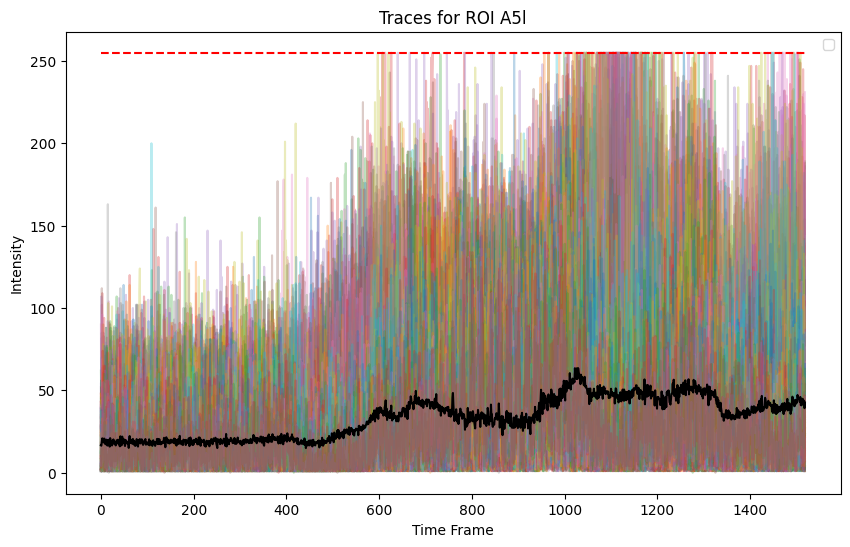

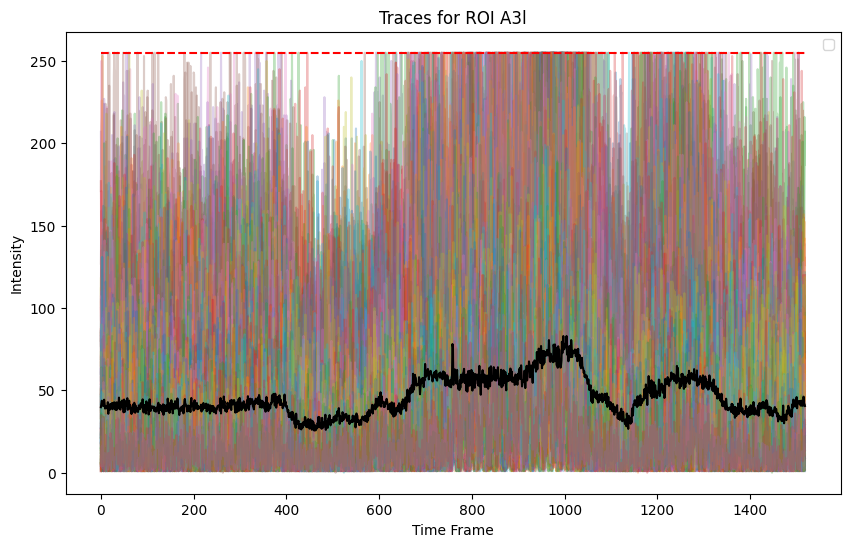

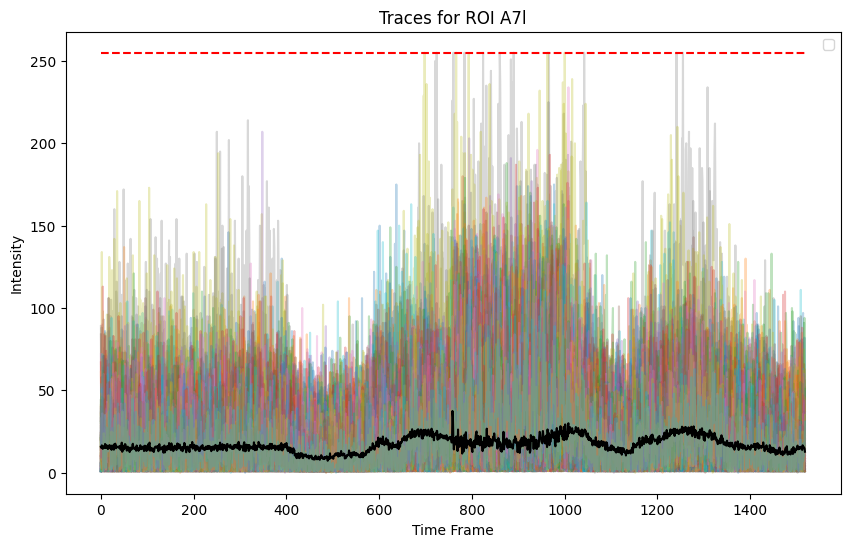

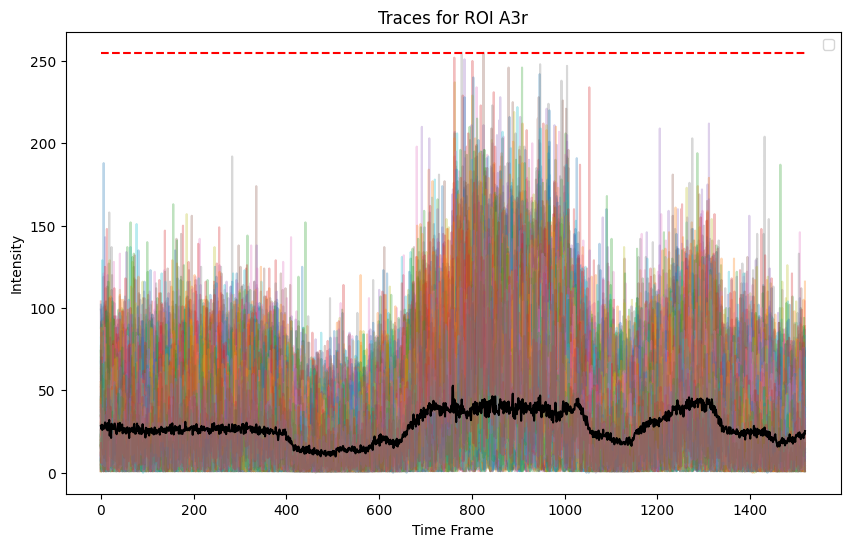

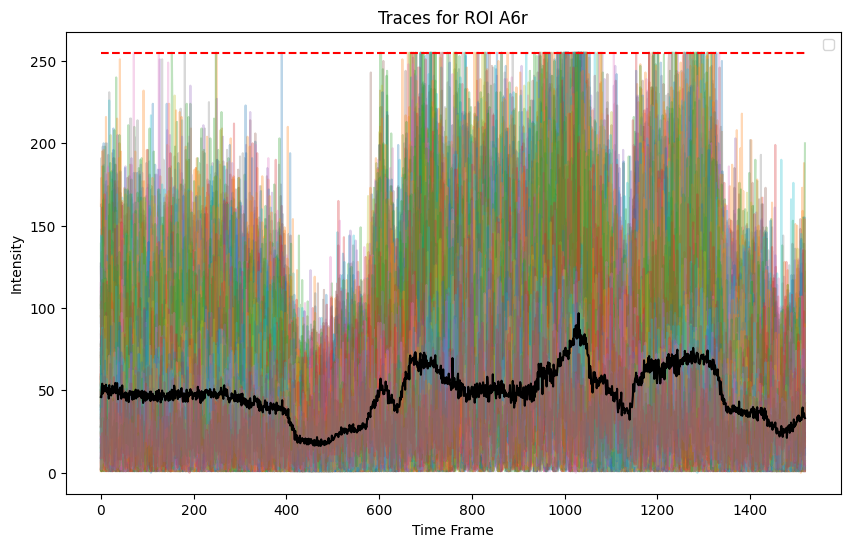

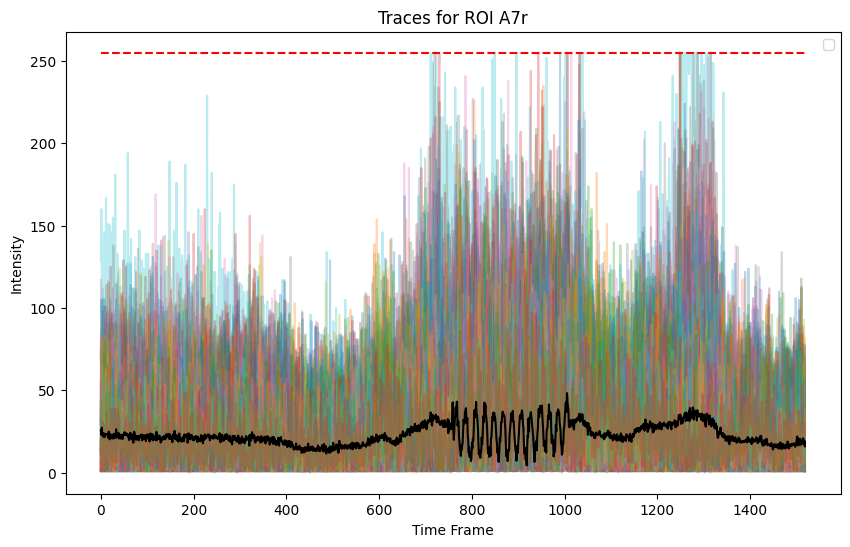

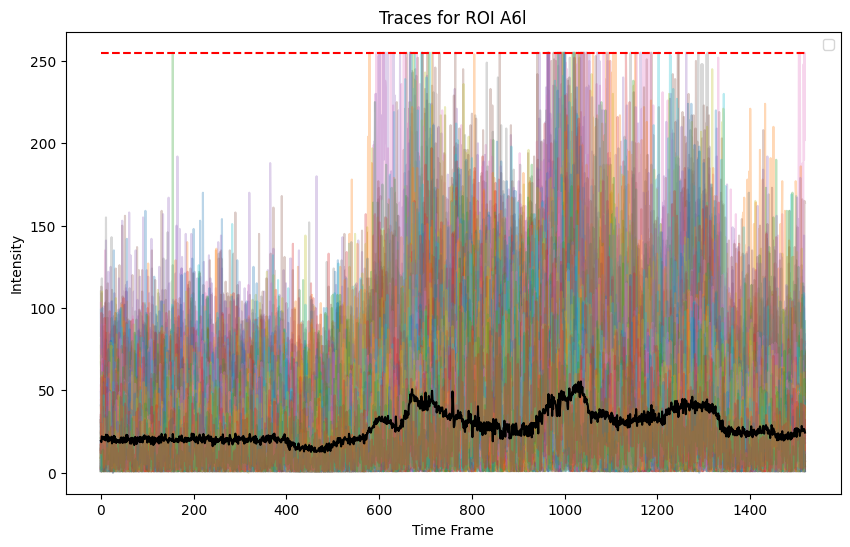

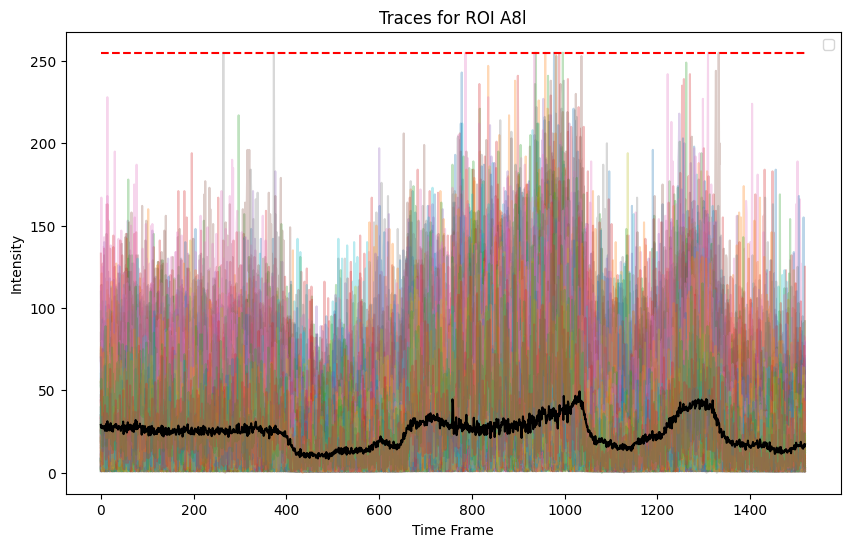

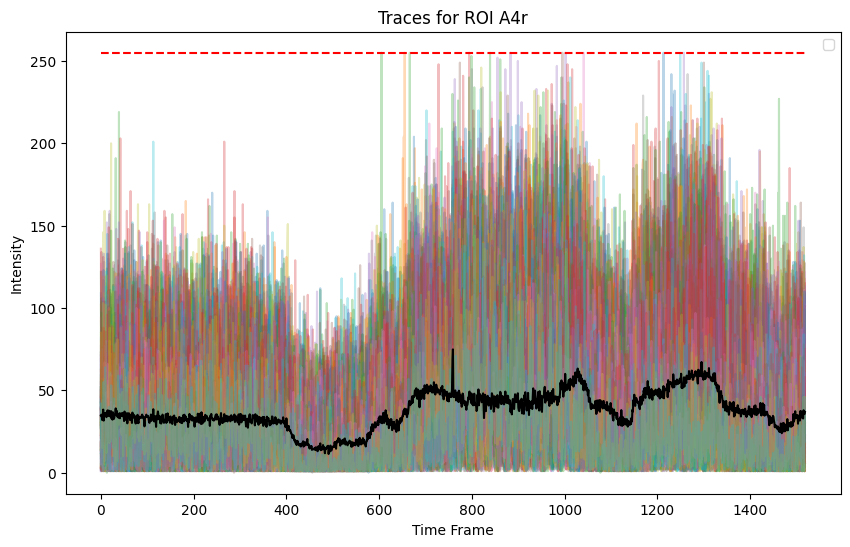

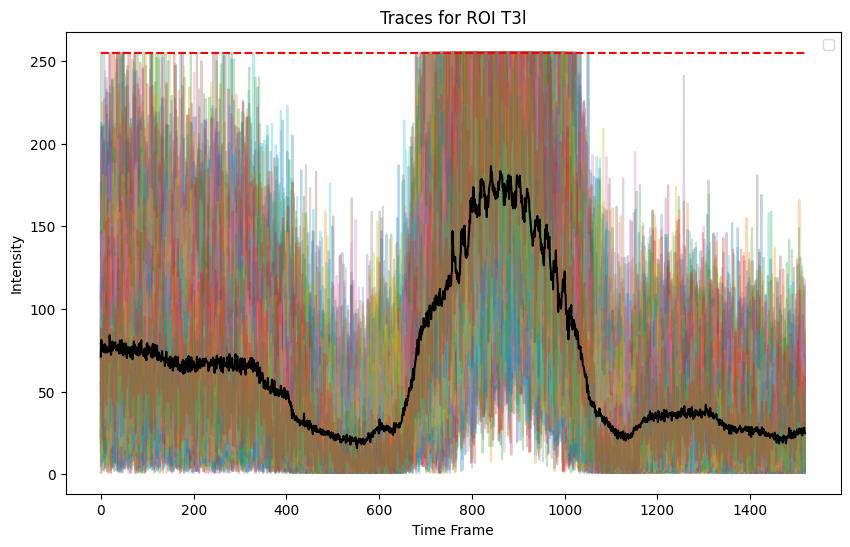

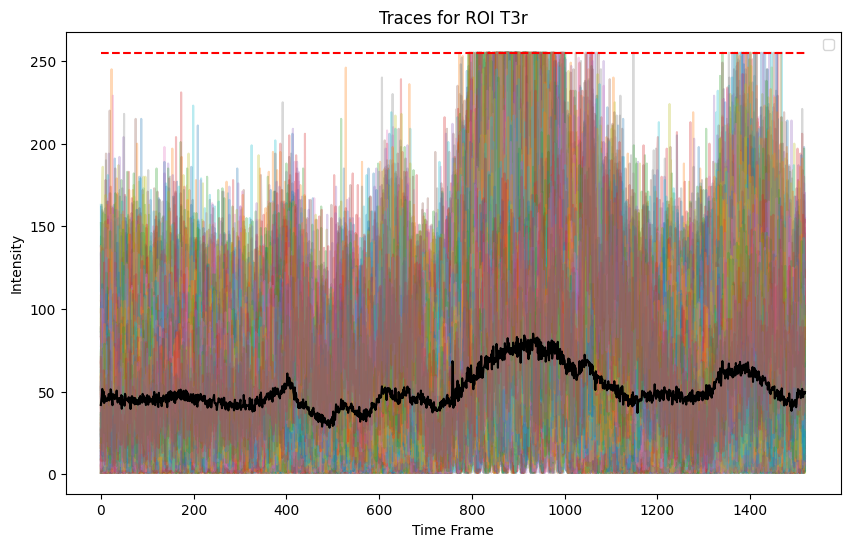

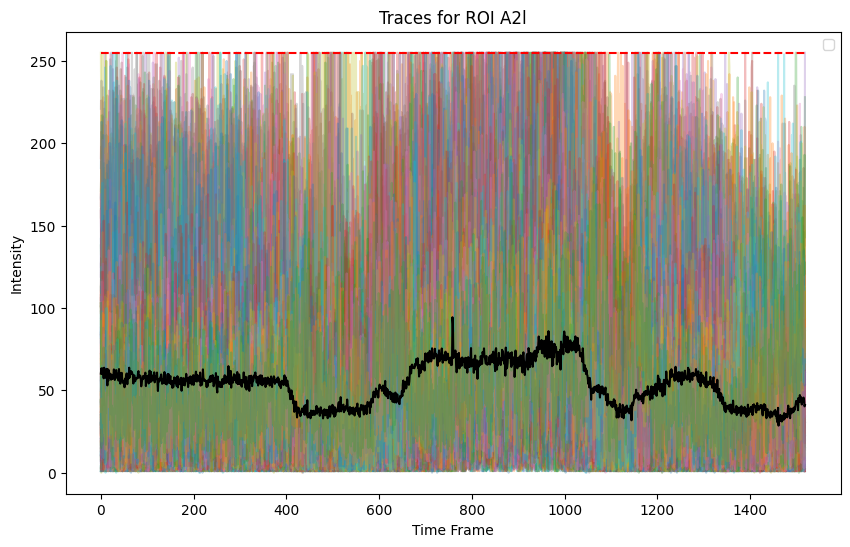

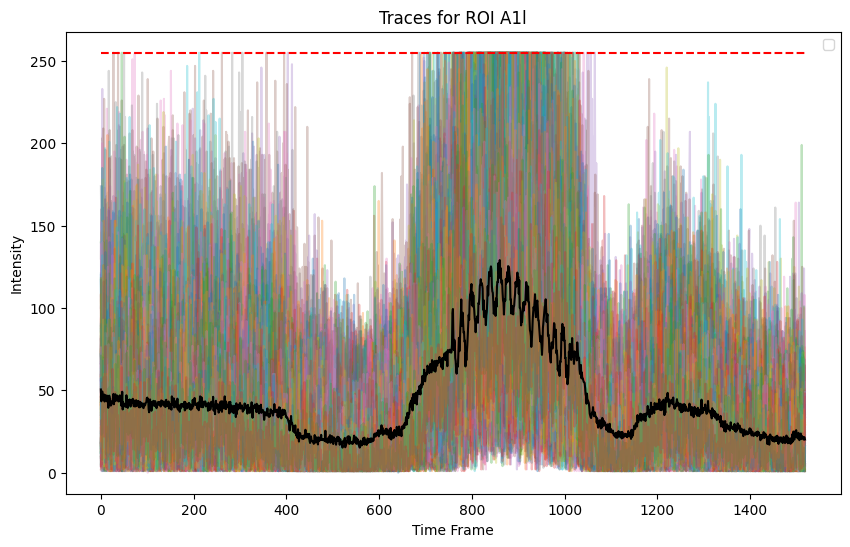

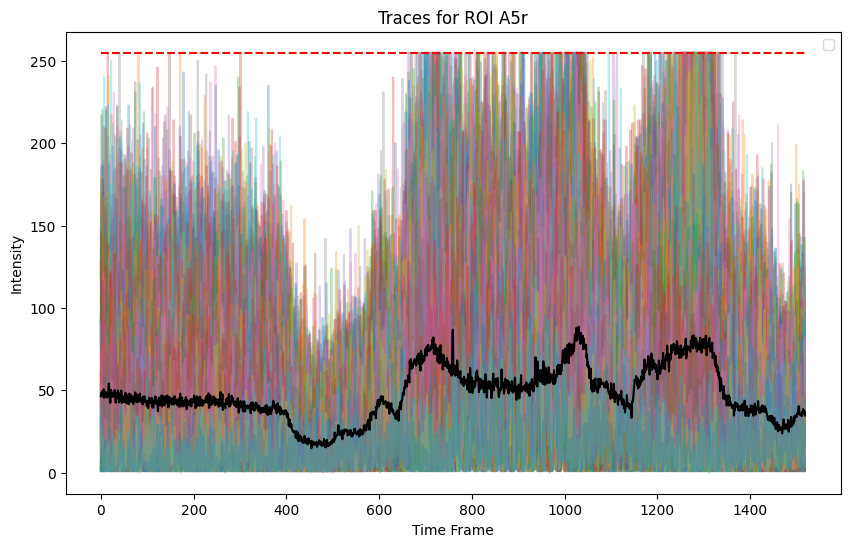

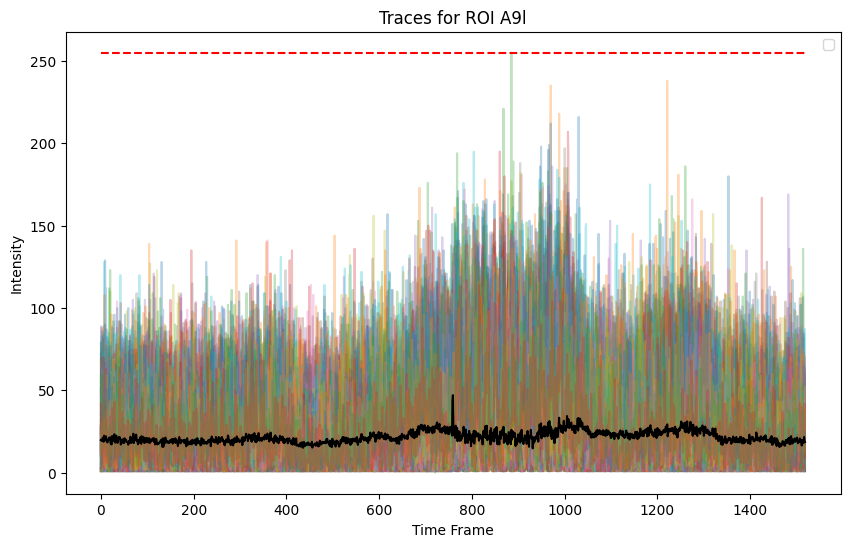

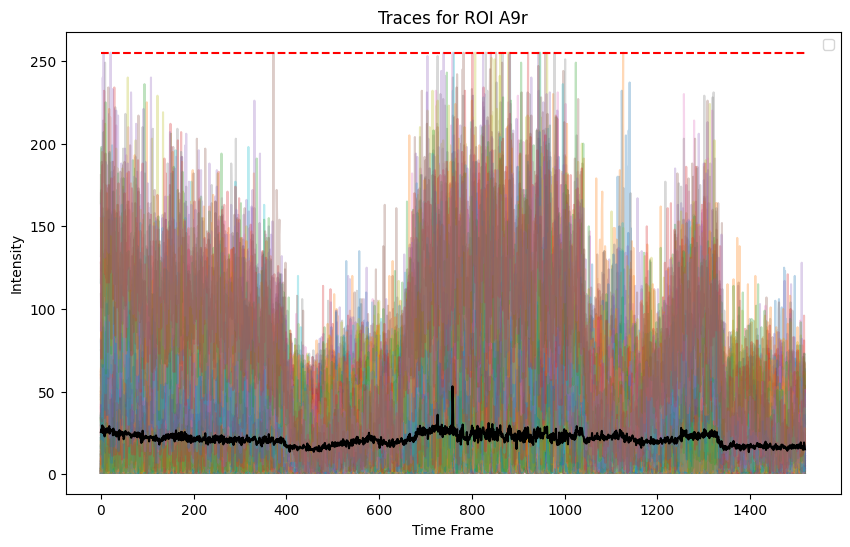

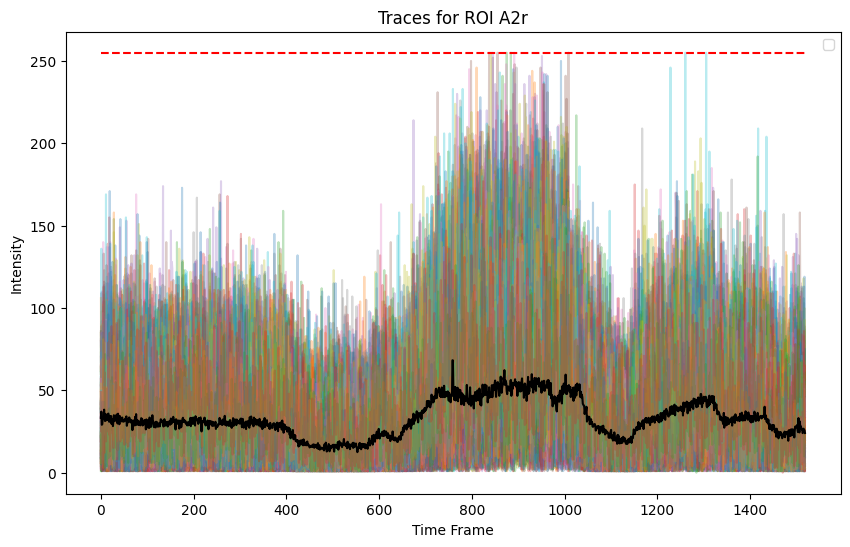

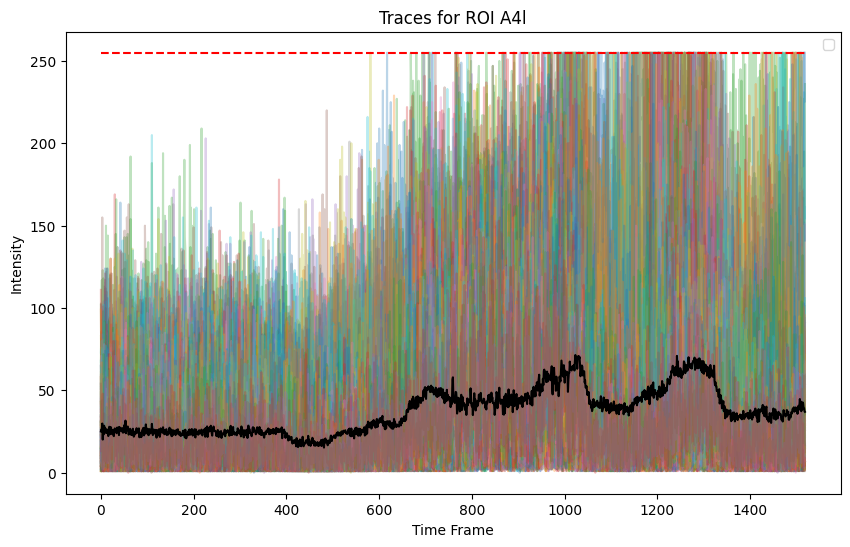

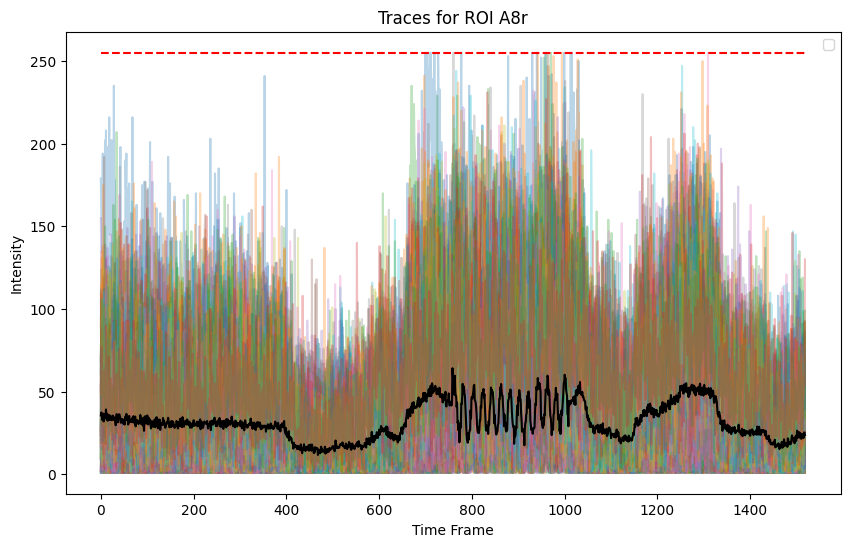

In [72]:
###########################             ###########################
########################### DETAILED PLOTTING ###########################
###########################             ###########################


# from dictionaries dict_rois_baseline, dict_rois_df, dict_rois_df_f, each key corresponds to ROI of my image, and the values are baseline, df, df_f, I will plot the trace of each pixels baseline&image_filtered, and df_ff or each value for each roi

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_traces(dict_rois_baseline, dict_rois_df_f, dict_rois_name_xy):
    """Plots the traces of baseline and df/f for each ROI."""
    for roi_name in dict_rois_name_xy:
        baseline = dict_rois_baseline[roi_name]
        dff = dict_rois_df_f[roi_name]
        opto = dict_opto_df[roi_name]

        num_pixels = dff.shape[1]

        plt.figure(figsize=(10, 6))  # Adjust figure size as needed

        for pixel in range(num_pixels):

            plt.plot(dff[:,pixel] + baseline[:,pixel], alpha=0.3)
            #plt.plot(dff[:,pixel])

        plt.hlines(y=255, xmin=0, xmax=dff.shape[0], linestyles='dashed', colors='red')
        plt.plot(np.mean(dff[:] + baseline[:] -  opto[:], axis = 1), color = "black")
        plt.xlabel('Time Frame')
        plt.ylabel('Intensity')
        plt.title(f'Traces for ROI {roi_name}')
        plt.legend()
        plt.show()

plot_traces(dict_rois_baseline, dict_rois_df, dict_rois_name_xy)
# plot_ridge_plot(dict_rois_baseline, dict_rois_df_f, dict_rois_name_xy)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_traces_subplots(dict_rois_baseline, dict_rois_df_f, dict_rois_name_xy, dict_opto_df):
    """Plots the traces of baseline and df/f for each ROI in subplots."""
    roi_names = list(dict_rois_name_xy.keys())
    num_rois = len(roi_names)

    # Create a figure and a set of subplots
    # We create one subplot per ROI
    fig, axes = plt.subplots(num_rois, 1, figsize=(10, 4 * num_rois), sharex=True) # Adjust figure size and height per subplot

    # If there's only one ROI, axes will not be an array, so make it one for consistent indexing
    if num_rois == 1:
        axes = [axes]

    # Loop through ROIs and plot on their respective subplots
    for i, roi_name in enumerate(roi_names):
        baseline = dict_rois_baseline[roi_name]
        dff = dict_rois_df[roi_name]
        opto = dict_opto_df[roi_name]

        num_pixels = dff.shape[1]

        # Plot individual pixel traces (optional, can be commented out if too crowded)
        for pixel in range(num_pixels):
            axes[i].plot(dff[:, pixel] + baseline[:, pixel], alpha=0.3)

        # Plot the average trace
        # Calculate the average signal after subtracting the opto artifact contribution
        # Assuming opto_df contains the artifact to be subtracted from the signal itself
        # This might need adjustment based on how opto_df is calculated (e.g., if it's an additive artifact)
        # A common way to correct Df/F for an additive artifact A is (F - F0 - A) / F0 = Df/F - A/F0
        # If opto is the raw artifact signal, we subtract it from F + baseline which represents F.
        # Then compute the mean signal trace
        mean_signal_trace = np.mean(dff + baseline - opto, axis=1)
        axes[i].plot(mean_signal_trace, color="black", label='Average Trace')


        # Add horizontal line at a reference intensity
        axes[i].hlines(y=255, xmin=0, xmax=dff.shape[0], linestyles='dashed', colors='red')

        # Set labels and title for the current subplot
        axes[i].set_ylabel('Intensity')
        axes[i].set_title(f'Traces for ROI {roi_name}')
        axes[i].legend()

    # Set common x-axis label for the entire figure
    fig.text(0.5, 0.04, 'Time Frame', ha='center') # Place xlabel manually at the bottom

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent titles/labels overlapping, make space for the common xlabel
    plt.suptitle('Intensity Traces for Each ROI', y=0.99) # Add a main title for the entire figure
    plt.show()

# Assuming you have the following dictionaries from previous code execution:
# dict_rois_baseline, dict_rois_df_f, dict_rois_name_xy, dict_opto_df
# Replace the original plot_traces call with the new one:
plot_traces_subplots(dict_rois_baseline, dict_rois_df, dict_rois_name_xy, dict_opto_df)

In [ ]:
###########################             ###########################
########################### DETAILED PLOTTING ###########################
###########################             ###########################
#### plot average pixel trace for each ROI


num_rois = len(dict_rois_name_xy)
fig, axes = plt.subplots(num_rois, 1, figsize=(10, 6 * num_rois), sharex=True)

# Loop through ROIs and plot on respective subplots
for i,roi_name in enumerate(dict_rois_name_xy):

    dff = dict_rois_df_f[roi_name]
    opto_df = dict_opto_df[roi_name]
    baseline = dict_rois_baseline[roi_name]


    avg_pixel_df_f = np.mean(dff- opto_df/baseline, axis = 1)  # Calculate average dff across all pixels for this ROI

    axes[i].vlines(760, -1, 1, linestyles='dashed', colors='red')
    axes[i].plot(avg_pixel_df_f)  # Plot the average dff trace
    axes[i].set_ylabel('Intensity')
    axes[i].set_title(f'Average Pixel Trace for ROI {roi_name}')
    axes[i].set_ylim(-1,1)

# Set common x-axis label for the entire figure
plt.xlabel('Time Frame')
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()




In [ ]:
###########################             ###########################
########################### DETAILED PLOTTING ###########################
###########################             ###########################
############ smooth the data using Whittaker-Eiler filter
from whittaker_eilers import WhittakerSmoother
print()
whittaker_smoother = WhittakerSmoother(
    lmbda=100, order=1, data_length=(dict_rois_df_f['A6r'].shape[0])
)


num_rois = len(dict_rois_name_xy)
fig, axes = plt.subplots(num_rois, 1, figsize=(10, 6 * num_rois), sharex=True)

# Loop through ROIs and plot on respective subplots
for i,roi_name in enumerate(dict_rois_name_xy):

    dff = dict_rois_df_f[roi_name]
    opto_df = dict_opto_df[roi_name]
    baseline = dict_rois_baseline[roi_name]

    avg_pixel_df_f = np.mean(dff- opto_df/baseline, axis = 1)  # Calculate average dff across all pixels for this ROI

    smoothed_df_f = whittaker_smoother.smooth(avg_pixel_df_f)


    axes[i].plot(smoothed_df_f)  # Plot the average dff trace
    axes[i].set_ylabel('Intensity')
    axes[i].set_title(f'Average Pixel Trace for ROI {roi_name}')
    axes[i].set_ylim(-1,1)

# Set common x-axis label for the entire figure
plt.xlabel('Time Frame')
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()

In [ ]:
###########################                     ###########################
########################### IMPORTANT PLOTTING ###########################
###   plots smoothed average pixel per roi left and right overlaid     ###########################


import numpy as np
import matplotlib.pyplot as plt
from whittaker_eilers import WhittakerSmoother
import os
from google.colab import files



# Initialize the Whittaker smoother
whittaker_smoother = WhittakerSmoother(
    lmbda=100, order=1, data_length=(dict_rois_df_f['A6r'].shape[0])
)

num_rois = len(dict_rois_name_xy)
offset_height = 0.35 # Define vertical spacing between traces

fig, ax = plt.subplots(figsize=(10, 6), dpi=600 )

# Custom sorting function to prioritize 'T' ROIs
def sort_roi_names(roi_name):
    if roi_name.startswith('T'):
        return (0, roi_name)  # 'T' ROIs come first
    else:
        return (1, roi_name)  # Other ROIs come after

sorted_rois_name_xy = sorted(dict_rois_name_xy, key=sort_roi_names)

print(sorted_rois_name_xy)

# Loop through ROIs and plot with offsets
for i, roi_name in enumerate(sorted_rois_name_xy):



    if i % 2 == 0:  # Even index (left side ROIs)
        offset = -offset_height * (i )  # Divide by 2 for proper spacing
        color = 'pink'  # Set color to pink for left side
    else:  # Odd index (right side ROIs)
        offset = -offset_height * ((i - 1) )  # Divide by 2 for proper spacing
        color = 'gray'  # Set color to gray for right side

    dff = dict_rois_df_f[roi_name]
    baseline = dict_rois_baseline[roi_name]

    opto_df = dict_opto_df[roi_name]

    avg_pixel_df_f = np.mean(dff- opto_df/baseline, axis = 1)  # Calculate average dff across all pixels for this ROI
    smoothed_df_f = np.array(whittaker_smoother.smooth(avg_pixel_df_f))

    # Plot the smoothed trace with offset

    # ax.plot(np.mean(opto_df[:, np.newaxis]/baseline, axis=1), color="red")

    ax.plot(smoothed_df_f + offset, color=color)


    # Add text label next to the trace
    ax.text(len(smoothed_df_f), smoothed_df_f[-1] + offset, roi_name, color=color,
            ha='left', va='center')

    # Add a zero line for the current offset
    ax.plot(np.zeros_like(smoothed_df_f) + offset, color='black', linestyle='--', linewidth=0.5, alpha=0.8, zorder=1)  # Added alpha and zorder for visibility

ax.set_yticks([])
# Set labels and legend
ax.set_xlabel('Time Frame')
ax.set_ylabel('ΔF/F0')
ax.legend(loc='upper right')  # You might want to adjust the legend to include the zero line
plt.title('Smoothed Traces with Vertical Offset and Zero Lines')

save_path = '/content/Smoothed_Traces.png'  # Save to Colab's content directory

plt.savefig(save_path)  # Save the figure
plt.show()

# Download the saved figure to your computer
#files.download(save_path)

In [ ]:
###########################             ###########################
########################### CORRELATION MATRIX ###########################
###########################             ###########################
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats


stimulus_start = input("Please enter stimulus start frame (enter is default: frame 760): ")
stimulus_start = int(stimulus_start) if stimulus_start else 760
print(stimulus_start)
stimulus_duration = input("Please enter stimulus duration (enter is default: 250 frames): ")
stimulus_duration = int(stimulus_duration) if stimulus_duration else 250
print(stimulus_duration)

# Custom sorting function to prioritize 'T' ROIs
def sort_roi_names(roi_name):
    if roi_name.startswith('T'):
        return (0, roi_name)  # 'T' ROIs come first
    else:
        return (1, roi_name)  # Other ROIs come after

sorted_roi_names = sorted(dict_rois_name_xy, key=sort_roi_names)

print(sorted_rois_name_xy)

########## calculate smooth avf trace

dict_smooth_avg_pixel_df_f = dict()
# Loop through ROIs
for i,roi_name in enumerate(dict_rois_df_f):

    dff = dict_rois_df_f[roi_name]

    opto_df = dict_opto_df[roi_name]
    baseline = dict_rois_baseline[roi_name]

    avg_pixel_df_f = np.mean(dff- opto_df/baseline, axis = 1)  # Calculate average dff across all pixels for this ROI

    smoothed_df_f = np.array(whittaker_smoother.smooth(avg_pixel_df_f))

    dict_smooth_avg_pixel_df_f[roi_name] = smoothed_df_f

# Create an empty correlation matrix
num_rois = len(sorted_roi_names)
correlation_matrix = np.zeros((num_rois, num_rois))

# Calculate correlations between all pairs of ROIs (using sorted roi_names)

for i in range(num_rois):
    for j in range(i + 1, num_rois):  # Avoid redundant calculations
        roi1_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[i]]
        roi2_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[j]]
        correlation, _ = stats.pearsonr(roi1_data, roi2_data)
        correlation_matrix[i, j] = correlation_matrix[j, i] = correlation

# Create a Pandas DataFrame for the correlation matrix (using sorted roi_names)
df_corr = pd.DataFrame(correlation_matrix, index=sorted_roi_names, columns=sorted_roi_names)

# Plot the correlation matrix using Seaborn heatmap
plt.figure(figsize=(10, 8), dpi = 600)  # Adjust figure size as needed
sns.heatmap(df_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of ROIs (Ordered)')
plt.tight_layout()

save_path = '/content/Correlation Matrix of ROIs (Ordered).png'  # Save to Colab's content directory

plt.savefig(save_path)  # Save the figure

plt.show()

# Download the saved figure to your computer
files.download(save_path)

plt.figure(figsize=(10, 8), dpi = 600)  # Adjust figure size as needed
# Clustered ordering based on correlation
linkage = sns.clustermap(df_corr, method="average", metric="euclidean", row_cluster=True, col_cluster=True, figsize=(10, 8), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Clustered Correlation Matrix of ROIs')
save_path = '/content/Clustered Correlation Matrix of ROIs.png'  # Save to Colab's content directory
plt.savefig(save_path)  # Save the figure
plt.show()
# Download the saved figure to your computer
files.download(save_path)




# Calculate correlations between all pairs of ROIs (using sorted roi_names) DURINF STIMULUS ONLY

for i in range(num_rois):
    for j in range(i + 1, num_rois):  # Avoid redundant calculations
        roi1_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[i]][stimulus_start:stimulus_start+stimulus_duration]
        roi2_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[j]][stimulus_start:stimulus_start+stimulus_duration]
        correlation, _ = stats.pearsonr(roi1_data, roi2_data)
        correlation_matrix[i, j] = correlation_matrix[j, i] = correlation

# Create a Pandas DataFrame for the correlation matrix (using sorted roi_names)
df_corr = pd.DataFrame(correlation_matrix, index=sorted_roi_names, columns=sorted_roi_names)

# Plot the correlation matrix using Seaborn heatmap
plt.figure(figsize=(10, 8), dpi = 600)  # Adjust figure size as needed
sns.heatmap(df_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of ROIs DURING STIMULATION (Ordered)')
plt.tight_layout()
save_path = '/content/Correlation Matrix of ROIs DURING STIMULATION.png'  # Save to Colab's content directory
plt.savefig(save_path)  # Save the figure
plt.show()

# Download the saved figure to your computer
files.download(save_path)

plt.figure(figsize=(10, 8), dpi = 600)  # Adjust figure size as needed
# Clustered ordering based on correlation
linkage = sns.clustermap(df_corr, method="average", metric="euclidean", row_cluster=True, col_cluster=True, figsize=(10, 8), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Clustered Correlation Matrix DURING STIMULATION')
save_path = '/content/CLUSTERED Correlation Matrix of ROIs DURING STIMULATION.png'  # Save to Colab's content directory
plt.savefig(save_path)  # Save the figure
plt.show()

# Download the saved figure to your computer
files.download(save_path)


# # Calculate correlations between all pairs of ROIs (using sorted roi_names) AFTER STIMULUS

# for i in range(num_rois):
#     for j in range(i + 1, num_rois):  # Avoid redundant calculations
#         roi1_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[i]][stimulus_start:-1]
#         roi2_data = dict_smooth_avg_pixel_df_f[sorted_roi_names[j]][stimulus_start:-1]
#         correlation, _ = stats.pearsonr(roi1_data, roi2_data)
#         correlation_matrix[i, j] = correlation_matrix[j, i] = correlation

# # Create a Pandas DataFrame for the correlation matrix (using sorted roi_names)
# df_corr = pd.DataFrame(correlation_matrix, index=sorted_roi_names, columns=sorted_roi_names)

# # Plot the correlation matrix using Seaborn heatmap
# plt.figure(figsize=(10, 8))  # Adjust figure size as needed
# sns.heatmap(df_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
# plt.title('Correlation Matrix of ROIs (Ordered)')
# plt.tight_layout()
# plt.show()


# # Clustered ordering based on correlation
# linkage = sns.clustermap(df_corr, method="average", metric="euclidean", row_cluster=True, col_cluster=True, figsize=(10, 8), cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
# plt.title('Clustered Correlation Matrix of ROIs AFTER STIMULATION')
# plt.show()

In [ ]:
###########################             ###########################
########################### SAVING DATA IN MANY FILES ###########################
###########################             ###########################


#### SAVE THE DATA

# store in csv, traces of of each pixel in each ROIs (116 pixels each) along time series (1519 time points) for dF/F and baseline

# csv for each measure , have pixel number --> time series

import csv

Baseline_file = 'Baseline_Values_Allpixels_perROIs'+ image.strip('.tif')+'.csv'
DF_F0_file = 'DF_F0_Values_Allpixels_perROIs'+ image.strip('.tif')+'.csv'

with open(Baseline_file, "w", newline="") as f:

    header = list(dict_rois_baseline.keys()) # Get the keys of the dictionary as a list
    # make this list 116(number of pixels) times bigger to have header for every value
    repeated_header = []

    for item in header:
      repeats = (dict_rois_baseline[item].shape)[1]

      repeated_header.extend([item] * repeats)

    w = csv.writer(f) # Use csv.writer instead of csv.DictWriter

    w.writerow(repeated_header) # Write the header row with ROI names

    # Since the data is a 3D array, we need to iterate and write each row
    for i in range(dict_rois_baseline[header[0]].shape[0]): # Iterate through rows (time points)
        row_data = [dict_rois_baseline[roi_name][i,:] for roi_name in header] # Extract data for each ROI for this row
        # Flatten the row_data list to write as a single row in the CSV
        flattened_row_data = [item for sublist in row_data for item in sublist]
        w.writerow(flattened_row_data) # Write data for each ROI in this timepoint/row



with open(DF_F0_file, "w", newline="") as f:

    header = list(dict_rois_df_f.keys()) # Get the keys of the dictionary as a list
    # make this list 116(number of pixels) times bigger to have header for every value
    repeated_header = []

    for item in header:
      repeats = (dict_rois_df_f[item].shape)[1]

      repeated_header.extend([item] * repeats)

    w = csv.writer(f) # Use csv.writer instead of csv.DictWriter

    w.writerow(repeated_header) # Write the header row with ROI names

    # Since the data is a 3D array, we need to iterate and write each row
    for i in range(dict_rois_df_f[header[0]].shape[0]): # Iterate through rows (time points)
        row_data = [dict_rois_df_f[roi_name][i,:] for roi_name in header] # Extract data for each ROI for this row
        # Flatten the row_data list to write as a single row in the CSV
        flattened_row_data = [item for sublist in row_data for item in sublist]
        w.writerow(flattened_row_data) # Write data for each ROI in this timepoint/row



In [ ]:

dict_avg_pixel_df_f = dict()
# Loop through ROIs
for i,roi_name in enumerate(dict_rois_df_f):

    dff = dict_rois_df_f[roi_name]

    opto_df = dict_opto_df[roi_name]
    baseline = dict_rois_baseline[roi_name]

    dict_avg_pixel_df_f[roi_name] =  np.mean(dff-opto_df/baseline, axis = 1)  # Average dF/F for this ROI and correct for opto artifact

my_dict = dict_avg_pixel_df_f

Average_DF_F0_file = 'Average_DF_F0_Values_1pixel_perROIs'+ image.strip('.tif')+'.csv'


with open(Average_DF_F0_file, "w", newline="") as f:


      header = list(dict_rois_baseline.keys())
      w = csv.writer(f)

      w.writerow(header) # Write the header row with ROI names
      for i in range(dict_avg_pixel_df_f[header[0]].shape[0]): # Iterate through rows (time points)

        row_data = [dict_avg_pixel_df_f[roi_name][i] for roi_name in header] # Extract data for each ROI for this row
        # Flatten the row_data list to write as a single row in the CSV
        w.writerow(row_data) # Write data for each ROI in this timepoint/row



In [ ]:
####### STORE SMOOTH TRACE

from whittaker_eilers import WhittakerSmoother

# Initialize the Whittaker smoother
whittaker_smoother = WhittakerSmoother(
    lmbda=100, order=1, data_length=(dict_rois_df_f['A6r'].shape[0])
)



dict_smooth_avg_pixel_df_f = dict()
# Loop through ROIs
for i,roi_name in enumerate(dict_rois_df_f):

    dff = dict_rois_df_f[roi_name]
    opto_df = dict_opto_df[roi_name]
    baseline = dict_rois_baseline[roi_name]

    avg_pixel_df_f = np.mean(dff- opto_df/baseline, axis = 1)  # Calculate average dff across all pixels for this ROI

    dict_avg_pixel_df_f[roi_name] = avg_pixel_df_f
    smoothed_df_f = np.array(whittaker_smoother.smooth(avg_pixel_df_f))

    dict_smooth_avg_pixel_df_f[roi_name] = smoothed_df_f


Smooth_Average_DF_F0_file = 'Smooth_Average_DF_F0_Values_1pixel_perROIs'+ image.strip('.tif')+'.csv'

with open(Smooth_Average_DF_F0_file, "w", newline="") as f:


      header = list(dict_rois_baseline.keys())
      w = csv.writer(f)

      w.writerow(header) # Write the header row with ROI names
      for i in range(dict_smooth_avg_pixel_df_f[header[0]].shape[0]): # Iterate through rows (time points)

        row_data = [dict_smooth_avg_pixel_df_f[roi_name][i] for roi_name in header] # Extract data for each ROI for this row
        # Flatten the row_data list to write as a single row in the CSV
        w.writerow(row_data) # Write data for each ROI in this timepoint/row





In [ ]:
from google.colab import files
files.download('/content/Baseline_Values_Allpixels_perROIs'+ image.strip('.tif')+'.csv')
files.download('/content/DF_F0_Values_Allpixels_perROIs'+ image.strip('.tif')+'.csv')
files.download('/content/Average_DF_F0_Values_1pixel_perROIs'+ image.strip('.tif')+'.csv')
files.download('/content/Smooth_Average_DF_F0_Values_1pixel_perROIs'+ image.strip('.tif')+'.csv')

In [ ]:
##### in txt file
import csv
csv_file = input(Average_DF_F0_file)
txt_file = input('paste above image name but replace with.txt')
with open(txt_file, "w") as my_output_file:
    with open(csv_file, "r") as my_input_file:
        [ my_output_file.write(" ".join(row)+'\n') for row in csv.reader(my_input_file)]
    my_output_file.close()

In [ ]:
##### STORE IT ALONG COLUMNS INSTEAD
###### not useful

dict_avg_pixel_df_f = {}

# Compute the mean across axis=1 (rows) for each ROI
for roi_name, dff in dict_rois_df_f.items():
    dict_avg_pixel_df_f[roi_name] = np.mean(dff, axis=1)  # Mean along axis 1

# Get ROI names (these will be row headers)
roi_names = list(dict_avg_pixel_df_f.keys())

# Get the number of time points from the first ROI
num_timepoints = len(dict_avg_pixel_df_f[roi_names[0]])

# Open file for writing
with open("ROW_Average_DF_F0_Values_Headcast_perROIs.csv", "w", newline="") as f:
    w = csv.writer(f)

    # Write header (time points: 0, 1, 2, ..., 1518)
    timepoint_labels = [f"t{i}" for i in range(num_timepoints)]
    w.writerow(["ROI"] + timepoint_labels)  # First column is "ROI" names

    # Write each ROI's data as a row
    for roi_name in roi_names:
        row_data = [roi_name] + list(dict_avg_pixel_df_f[roi_name])  # ROI name + its time series
        w.writerow(row_data)



In [ ]:
# erase all the files and folders in content

# !rm -rf /content/*
